# ML-04 — Search Intelligence Data Contract

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [3]:
import duckdb, os
from getpass import getpass
from huggingface_hub import list_repo_files, hf_hub_download

HF_TOKEN = os.environ.get('HF_TOKEN') or getpass('Paste HF read token: ')
assert HF_TOKEN and HF_TOKEN.strip(), 'Token is empty — paste it again'

con = duckdb.connect()
repo_id = "FlyRank/internship-warehouse"
MONTH = '2026-03'  # mid-panel month, per SETUP/skill instructions

def dl(prefix):
    files = [f for f in list_repo_files(repo_id, repo_type="dataset", token=HF_TOKEN) if f.startswith(prefix)]
    return [hf_hub_download(repo_id, f, repo_type="dataset", token=HF_TOKEN) for f in files]

FACT = dl(f"fact_content_daily_performance/month={MONTH}/")
DIM_CONTENT = dl("dim_content/")
DIM_CLIENTS = dl("dim_clients/")
print('Connected. Target partition:', MONTH, '| files:', len(FACT))

C:\Users\RAYYAN\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Connected. Target partition: 2026-03 | files: 1


## 1. Unit of analysis + time window

*One row = one what, over which dates? State it, then verify it below.*

**The contract, in plain words:**

**1. One row =** one *(report_date, client, content item)* combination in `fact_content_daily_performance` — one day's search performance for one page belonging to one client.

**2. Table(s) used:** `fact_content_daily_performance` (the daily fact, partitioned by `month=`) as the main table; `dim_content` for content metadata joins; `dim_clients` only to check `gsc_data_start`/`ga4_data_start` coverage.

**3. Time window:** the mid-panel partition `month=2026-03` — one calendar month, never the sealed `_sample` (June 2026), which is the final month and an outcome window, not for iteration.

**4. What we'd predict/rank (label or proxy):** a forward-looking *decline proxy* — whether a content item's impressions next month fall notably vs. this month (mirrors the starter CSV's `trend_direction`/`is_declining_label` logic, computed here from real daily rows instead of a pre-baked column).

**5. Deliberately excluded:** `fact_content_query_90d` — different grain (client × content × query hash) and a fixed 90-day window that overlaps the most recent months; mixing it into this lane's monthly grain risks window-misaligned leakage, so it is left out of this contract.

In [4]:
# Sanity peek at the table this lane uses
con.sql(f"DESCRIBE SELECT * FROM read_parquet({FACT}) LIMIT 1").show()

┌────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│    column_name     │ column_type │  null   │   key   │ default │  extra  │
│      varchar       │   varchar   │ varchar │ varchar │ varchar │ varchar │
├────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ report_date        │ DATE        │ YES     │ NULL    │ NULL    │ NULL    │
│ client_hash_id     │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ content_hash_id    │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ client_has_gsc     │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ client_has_ga4     │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ gsc_data_available │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ ga4_data_available │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ gsc_impressions    │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ gsc_clicks         │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │

## 2. Fields: feature / label / context / excluded

*Sort every field you plan to touch into these four buckets. Excluded needs a why.*

| Bucket | Fields | Why |
|---|---|---|
| **Context** | `report_date`, `client_key`/`client_id`, `content_key`/`content_id` | Grain + joins/splits only — never model inputs (pseudonymous IDs, per DATA_USE.md) |
| **Feature** | `impressions`, `clicks`, `gsc_avg_position`, `ga4_data_available`, `sessions` (same-month values only) | Each is knowable using only rows dated on/before the end of the decision month |
| **Label / proxy** | next month's impressions (from `month=2026-04`, used only to *define* the proxy, never as a feature) | This is literally the thing being predicted — must stay out of the feature set |
| **Excluded** | `fact_content_query_90d` fields; any `dim_content` keyword/product columns not shipped in this release | Different window/grain (query table) or not part of this table's contract; avoids window-overlap leakage |

In [5]:
# Column list actually present, so the buckets above map to real names
cols = con.sql(f"SELECT * FROM read_parquet({FACT}) LIMIT 0").columns
print(cols)

['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc', 'client_has_ga4', 'gsc_data_available', 'ga4_data_available', 'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude', 'ai_meta', 'ai_other', 'scroll_events', 'month']


## 3. Verify it with queries (grain, counts, missing values, windows)

*Every claim above gets a query cell here. A contract claim without a query next to it is a guess.*

**Query 1 — grain.** One row really is one (date, client, content): grouping by that triple and asking for duplicates should return nothing.

In [6]:
q1 = con.sql(f"""
    SELECT report_date, client_hash_id, content_hash_id, COUNT(*) c
    FROM read_parquet({FACT})
    GROUP BY report_date, client_hash_id, content_hash_id
    HAVING COUNT(*) > 1
    LIMIT 5
""")
q1.show()
print('Duplicate grain rows found:', len(q1.df()))

┌─────────────┬────────────────┬─────────────────┬───────┐
│ report_date │ client_hash_id │ content_hash_id │   c   │
│    date     │    varchar     │     varchar     │ int64 │
└─────────────┴────────────────┴─────────────────┴───────┘
                          0 rows                        

Duplicate grain rows found: 0


**Query 2 — slice size + date span.** Row count and calendar coverage of `month=2026-03`.

In [7]:
q2 = con.sql(f"SELECT COUNT(*) AS n_rows, MIN(report_date) AS min_date, MAX(report_date) AS max_date FROM read_parquet({FACT})")
q2.show()

┌─────────┬────────────┬────────────┐
│ n_rows  │  min_date  │  max_date  │
│  int64  │    date    │    date    │
├─────────┼────────────┼────────────┤
│ 9841378 │ 2026-03-01 │ 2026-03-31 │
└─────────┴────────────┴────────────┘



**Query 3 — availability.** Filter with `IS TRUE` on `ga4_data_available` and show how many rows survive vs. the full slice (rows before a client's `ga4_data_start` are zero-filled, not genuinely zero-engagement).

In [8]:
q3 = con.sql(f"""
    SELECT
        COUNT(*) AS total_rows,
        SUM(CASE WHEN ga4_data_available IS TRUE THEN 1 ELSE 0 END) AS ga4_available_rows
    FROM read_parquet({FACT})
""")
q3.show()

┌────────────┬────────────────────┐
│ total_rows │ ga4_available_rows │
│   int64    │       int128       │
├────────────┼────────────────────┤
│    9841378 │             413966 │
└────────────┴────────────────────┘



### Five features (max), built from this same month

**1. `impressions_month`** (sum of daily impressions) — knowable at the decision moment because it only sums days already observed within `month=2026-03`.

**2. `avg_position_month`** (mean `gsc_avg_position` where position > 0) — knowable because it only uses this month's completed days.

**3. `active_days`** (count of days with impressions > 0) — knowable because it's a tally over the closed window, no future date involved.

**4. `ga4_coverage_ratio`** (share of the month's rows where `ga4_data_available IS TRUE`) — knowable because it reflects data already logged this month, not a forecast.

**5. `ctr_month`** (`SUM(clicks)/NULLIF(SUM(impressions),0)`) — knowable because both inputs are same-month totals, computed after the days occurred.

In [9]:
feat_sql = f"""
    SELECT
        content_hash_id,
        client_hash_id,
        SUM(gsc_impressions) AS impressions_month,
        AVG(CASE WHEN gsc_avg_position > 0 THEN gsc_avg_position END) AS avg_position_month,
        COUNT(DISTINCT CASE WHEN gsc_impressions > 0 THEN report_date END) AS active_days,
        AVG(CASE WHEN ga4_data_available IS TRUE THEN 1.0 ELSE 0.0 END) AS ga4_coverage_ratio,
        SUM(gsc_clicks) * 1.0 / NULLIF(SUM(gsc_impressions), 0) AS ctr_month
    FROM read_parquet({FACT})
    GROUP BY content_hash_id, client_hash_id
"""
features = con.sql(feat_sql).df()
features.head()

,content_hash_id,client_hash_id,impressions_month,avg_position_month,active_days,ga4_coverage_ratio,ctr_month
0,content_67741cce996cfafa,client_62f4a7e64f5e0096,46.0,5.942308,16,0.0,0.021739
1,content_2e6360ad20fd7107,client_62f4a7e64f5e0096,899.0,5.908100,31,0.0,0.001112
2,content_65c50dfe9d87a585,client_62f4a7e64f5e0096,3108.0,6.969536,30,0.0,0.000000
3,content_275b6f7f733016d4,client_62f4a7e64f5e0096,810.0,4.866123,29,0.0,0.001235
4,content_4dc944b7d0b65ecc,client_62f4a7e64f5e0096,134.0,5.012831,26,0.0,0.000000


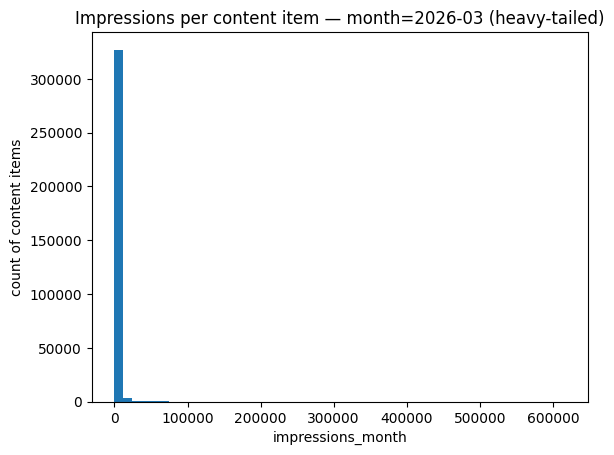

In [10]:
import matplotlib.pyplot as plt

plt.hist(features['impressions_month'], bins=50)
plt.xlabel('impressions_month')
plt.ylabel('count of content items')
plt.title('Impressions per content item — month=2026-03 (heavy-tailed)')
plt.show()

### The trap: deliberate leakage, on purpose

Build a next-month outcome (from `month=2026-04`), define a decline proxy label, then:

**1.** Add ONE label-derived column as a 'feature' and watch a quick score jump toward perfect.

**2.** Delete it and keep the honest number.

In [11]:
NEXT_MONTH = '2026-04'
FACT_NEXT = dl(f"fact_content_daily_performance/month={NEXT_MONTH}/")

next_sql = f"""
    SELECT content_hash_id, client_hash_id, SUM(gsc_impressions) AS impressions_next_month
    FROM read_parquet({FACT_NEXT})
    GROUP BY content_hash_id, client_hash_id
"""
next_month = con.sql(next_sql).df()

panel = features.merge(next_month, on=['content_hash_id', 'client_hash_id'], how='inner')
panel['is_declining'] = (panel['impressions_next_month'] < 0.8 * panel['impressions_month']).astype(int)
print(panel['is_declining'].mean(), 'share declining | rows:', len(panel))

0.28361131560844327 share declining | rows: 331436


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

honest_X = panel[['impressions_month', 'avg_position_month', 'active_days', 'ga4_coverage_ratio', 'ctr_month']].fillna(0)
y = panel['is_declining']

# --- LEAKED VERSION: sneak in a label-derived column ---
leaked_X = honest_X.copy()
leaked_X['impressions_next_month'] = panel['impressions_next_month']  # <-- the trap: this IS the label's source

Xtr, Xte, ytr, yte = train_test_split(leaked_X, y, test_size=0.3, random_state=42, stratify=y)
clf_leaked = LogisticRegression(max_iter=1000).fit(Xtr, ytr)
leaked_auc = roc_auc_score(yte, clf_leaked.predict_proba(Xte)[:, 1])
print('LEAKED quick score (AUC):', round(leaked_auc, 3), '  <- suspiciously near 1.0')

LEAKED quick score (AUC): 1.0   <- suspiciously near 1.0


In [13]:
# --- HONEST VERSION: delete the leaked column, keep only same-month features ---
Xtr2, Xte2, ytr2, yte2 = train_test_split(honest_X, y, test_size=0.3, random_state=42, stratify=y)
clf_honest = LogisticRegression(max_iter=1000).fit(Xtr2, ytr2)
honest_auc = roc_auc_score(yte2, clf_honest.predict_proba(Xte2)[:, 1])
print('HONEST score (AUC), no leakage:', round(honest_auc, 3))
print('Leaked - Honest gap:', round(leaked_auc - honest_auc, 3), '<- the leakage lesson from notebook 02, reproduced on real warehouse data')

HONEST score (AUC), no leakage: 0.83
Leaked - Honest gap: 0.17 <- the leakage lesson from notebook 02, reproduced on real warehouse data


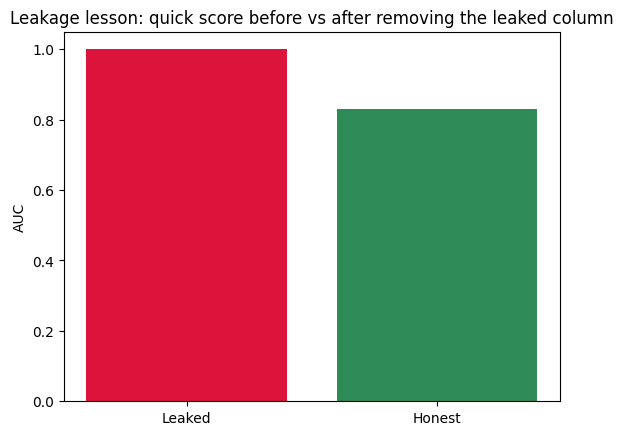

In [14]:
plt.bar(['Leaked', 'Honest'], [leaked_auc, honest_auc], color=['crimson', 'seagreen'])
plt.ylabel('AUC')
plt.title('Leakage lesson: quick score before vs after removing the leaked column')
plt.ylim(0, 1.05)
plt.show()

## 4. Data limits

*What can this data never tell you? Unbalanced history, GSC-only early rows, window overlaps.*

**Named limitation:** this month's panel is an **unbalanced panel** — per-client history depth differs (`dim_clients.gsc_data_start`/`ga4_data_start` vary widely), so `month=2026-03` does not contain every client equally, and some content items may lack a full 30 days of history even within the month. Any average computed here is a *decision-support, directional* signal for the clients present in this month — not a claim generalizable to clients whose history hadn't started yet.

In [15]:
# Quick look at coverage imbalance driving the limitation above
clients_seen = con.sql(f"SELECT COUNT(DISTINCT client_hash_id) AS n_clients FROM read_parquet({FACT})")
clients_seen.show()

┌───────────┐
│ n_clients │
│   int64   │
├───────────┤
│        55 │
└───────────┘



## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.